In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings



In [5]:
prices = pd.read_csv('delhi_prices.csv')
info = pd.read_csv('delhi_information.csv')

# Merge
df = pd.merge(prices, info, on='Flight ID')
# Basic informations
print("Size of dataset:", df.shape)
print("\nFirst 5 lines of data:")
print(df.head(5))


Size of dataset: (82481, 16)

First 5 lines of data:
   Flight ID Journey Date_x  Days Before Journey Date  Fare (Rupees)  \
0          1     06/03/2023                        50           9840   
1          2     06/03/2023                        50           9840   
2          3     16/01/2023                         1          11625   
3          4     23/01/2023                         8           9909   
4          5     30/01/2023                        15           8895   

   Fare (GBP) Journey Date_y Journey Day    Airline Flight Number    Class  \
0       98.40     06/03/2023      Monday    Vistara        UK-927  Economy   
1       98.40     06/03/2023      Monday    Vistara        UK-963  Economy   
2      116.25     16/01/2023      Monday  Air India        AI-885  Economy   
3       99.09     23/01/2023      Monday  Air India        AI-560  Economy   
4       88.95     30/01/2023      Monday  Air India        AI-542  Economy   

  Origin     Departure  Number Of Stops      

In [6]:
# Data cleaning
print("\nMissing value detection:")
print(df.isnull().sum())

print(df[['Fare (Rupees)', 'Airline', 'Days Before Journey Date']].describe())


Missing value detection:
Flight ID                   0
Journey Date_x              0
Days Before Journey Date    0
Fare (Rupees)               0
Fare (GBP)                  0
Journey Date_y              0
Journey Day                 0
Airline                     0
Flight Number               0
Class                       0
Origin                      0
Departure                   0
Number Of Stops             0
Arrival                     0
Destination                 0
Duration (Hours)            0
dtype: int64
       Fare (Rupees)  Days Before Journey Date
count   82481.000000              82481.000000
mean    20539.703483                 25.757423
std     18218.125648                 14.350843
min      2343.000000                  1.000000
25%      8234.000000                 13.000000
50%     11856.000000                 26.000000
75%     30249.000000                 38.000000
max    123260.000000                 50.000000


In [11]:
import pandas as pd

# 假设 df 是你合并后的数据
# 1. 按航线分组 (防止德里-孟买和德里-班加罗尔的价格混在一起比较)
df['Route'] = df['Origin'] + ' to ' + df['Destination']

# 2. 定义一个函数来检测每条航线内的异常值
def detect_outliers(group):
    Q1 = group['Fare (Rupees)'].quantile(0.25)
    Q3 = group['Fare (Rupees)'].quantile(0.75)
    IQR = Q3 - Q1
    # 定义异常值边界
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 3.0 * IQR # 这里放大上限，因为高价票通常是正常的商务需求
    
    # 标记异常
    group['Is_Outlier'] = (group['Fare (Rupees)'] < lower_bound) | (group['Fare (Rupees)'] > upper_bound)
    return group

# 应用函数
df_with_outliers = df.groupby('Route').apply(detect_outliers)

# 3. 查看被标记为异常的数据
expensive_anomalies = df_with_outliers[df_with_outliers['Is_Outlier']]
print("高价异常值 (可能包含定价错误或特殊舱位):")
print(expensive_anomalies[['Flight ID', 'Route', 'Fare (Rupees)', 'Days Before Journey Date', 'Airline']])

高价异常值 (可能包含定价错误或特殊舱位):
                          Flight ID               Route  Fare (Rupees)  \
Route                                                                    
Delhi to Hyderabad 2217        2218  Delhi to Hyderabad          75710   
                   2218        2219  Delhi to Hyderabad          75710   
                   21734      21597  Delhi to Hyderabad          77972   
                   21738      21601  Delhi to Hyderabad          77972   
                   21754      21617  Delhi to Hyderabad          74086   
...                             ...                 ...            ...   
Delhi to Mumbai    79928      79426     Delhi to Mumbai          96223   
                   80238      79736     Delhi to Mumbai          89598   
                   80256      79754     Delhi to Mumbai          95097   
                   80567      80065     Delhi to Mumbai          88366   
                   80603      80101     Delhi to Mumbai          90393   

              

C:\Users\ASUS\AppData\Local\Temp\ipykernel_8420\2852211445.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_with_outliers = df.groupby('Route').apply(detect_outliers)


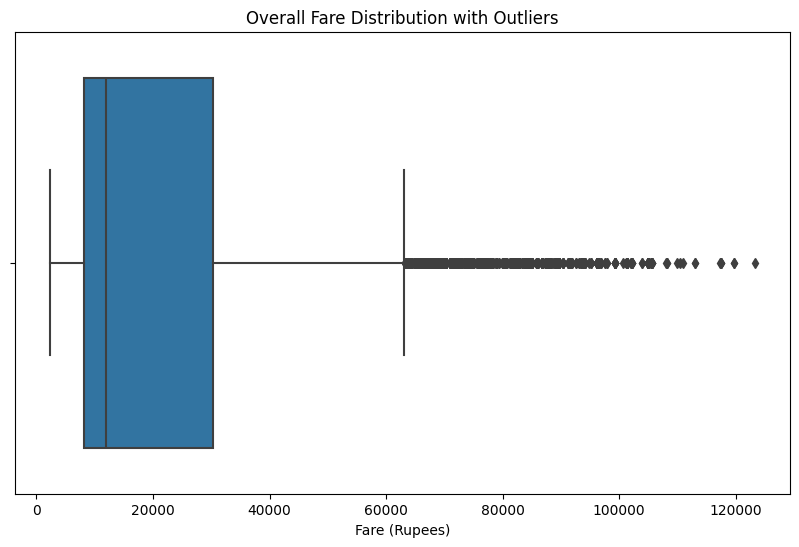

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Fare (Rupees)'])

plt.title('Overall Fare Distribution with Outliers')
plt.xlabel('Fare (Rupees)')
plt.show()

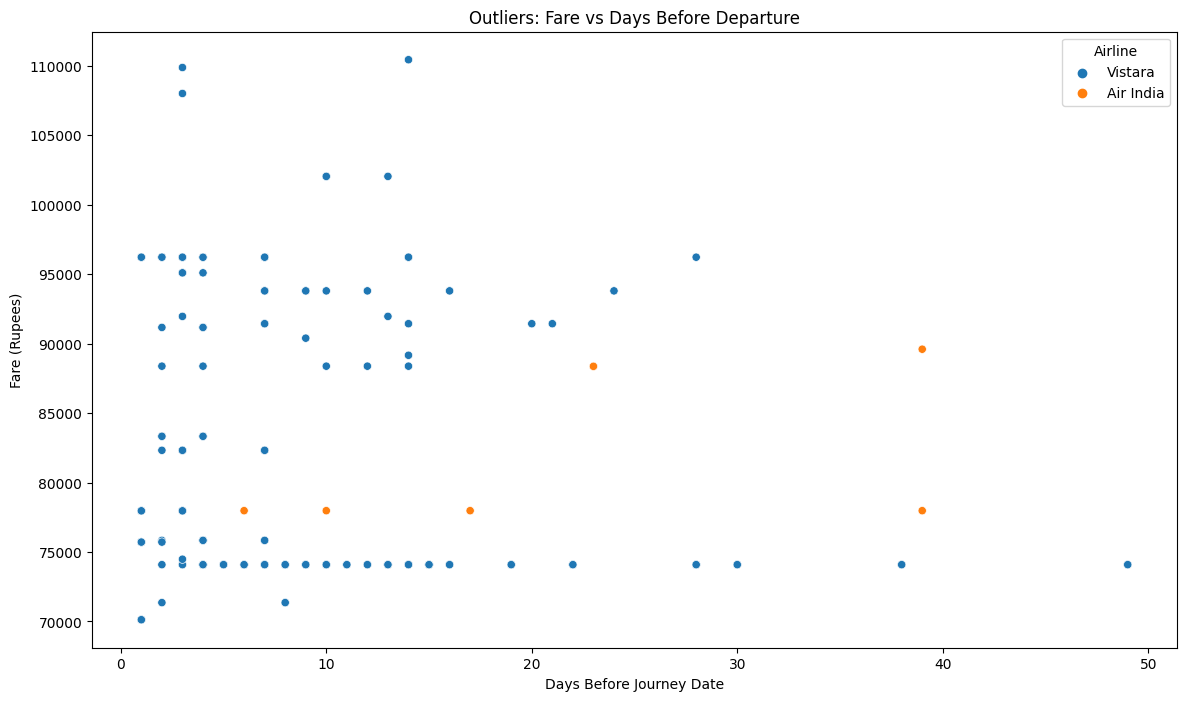

In [13]:
outliers = df_with_outliers[df_with_outliers['Is_Outlier']]

plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=outliers,
    x='Days Before Journey Date',
    y='Fare (Rupees)',
    hue='Airline'
)

plt.title('Outliers: Fare vs Days Before Departure')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# --- 新增：出发时段编码 ---
def time_of_day(departure):
    if '6 AM' in departure: return 'Morning'
    elif '12 PM' in departure: return 'Afternoon'
    elif '6 PM' in departure: return 'Evening'
    else: return 'Night'
df['Time_of_Day'] = df['Departure'].apply(time_of_day)

# --- 新增：提前天数的非线性特征 ---
# 航空业通常有“早鸟”和“最后一刻”高价
df['Is_Last_Minute'] = (df['Days Before Journey Date'] < 7).astype(int)
df['Is_Early_Bird'] = (df['Days Before Journey Date'] > 45).astype(int)

# 4. 准备特征矩阵
# 选择特征列
feature_cols = [
    'Days Before Journey Date',
    'Airline',
    'Destination',
    'Time_of_Day',
    'Is_Last_Minute',
    'Is_Early_Bird',
    'Number Of Stops',
    'Duration (Hours)'
]

X = pd.get_dummies(df[feature_cols], drop_first=True) # One-Hot Encoding
y = df['Fare (Rupees)']

# 1. 划分训练/测试集 (这里为了演示异常，我们直接用全量数据训练，或仅用训练集预测测试集)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 训练 XGBoost 回归模型
model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)

# 3. 预测与计算残差
y_pred = model.predict(X_test)
residuals = np.abs(y_test - y_pred) # 绝对误差

# 4. 识别异常：找出模型预测得非常不准的样本 (误差最大的前5%)
threshold = np.percentile(residuals, 95) # 95分位数
anomaly_indices = residuals[residuals > threshold].index

print(f"识别出 {len(anomaly_indices)} 个高异常样本 (模型预测误差极大)")

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


ModuleNotFoundError: No module named 'xgboost'

In [16]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.1/101.7 MB 4.3 MB/s eta 0:00:24
   ---------------------------------------- 0.2/101.7 MB 3.7 MB/s eta 0:00:28


ERROR: Exception:
Traceback (most recent call last):
  File "D:\python\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "D:\python\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ^^^^^^^^^^^^^^^^^^
  File "D:\python\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ^^^^^^^^^^^^^^^^^^
  File "D:\python\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 102, in read
    self.__buf.write(data)
  File "D:\python\Lib\tempfile.py", line 483, in func_wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
OSError: [Errno 28] No space left on device

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "D:\python\Lib\site-packages\pip\_internal\cli\base_command.py", l